In [1]:
import pandas as pd
import os
import time
from clickhouse_driver import Client
from datetime import datetime
import numpy as np
import traceback
import requests
from clickhouse_driver import Client
from dotenv import load_dotenv
from utils import *
import os

In [2]:
load_dotenv()

CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST", "localhost")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER", "default")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD", "")
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB", "default")

In [5]:
try:
        logging.info("=== Data Ingestion Process Started ===")
        # downloaded_file = download_file(URL, DATA_DIR)
        # extracted_file = decompress_file(downloaded_file)
        df = load_json_or_jsonl_pandas("/Users/alaindestinkarasira/Documents/SQL_Clickhouse/dataset_/files/Amazon_Fashion.jsonl")
        print (df.head(5))
        print(df.columns)

        # # Save DataFrame to parquet for next ingestion step (optional)
        # parquet_path = os.path.join(DATA_DIR, "amazon_reviews.parquet")
        # df.write_parquet(parquet_path)
        # logging.info(f"Saved cleaned data to {parquet_path}")
 
        # logging.info("=== Data Ingestion Process Completed Successfully ===")

except Exception as e:
        logging.error(f"Error during data ingestion: {e}", exc_info=True)
        raise


   rating                 title  \
0       5         Pretty locket   
1       5                     A   
2       2             Two Stars   
3       1       Won’t buy again   
4       5  I LOVE these glasses   

                                                text images        asin  \
0  I think this locket is really pretty. The insi...     []  B00LOPVX74   
1                                              Great     []  B07B4JXK8D   
2  One of the stones fell out within the first 2 ...     []  B007ZSEQ4Q   
3  Crappy socks. Money wasted. Bought to wear wit...     []  B07F2BTFS9   
4  I LOVE these glasses!  They fit perfectly over...     []  B00PKRFU4O   

  parent_asin                       user_id               timestamp  \
0  B00LOPVX74  AGBFYI2DDIKXC5Y4FARTYDTQBMFQ 2020-01-09 00:06:34.489   
1  B07B4JXK8D  AFQLNQNQYFWQZPJQZS6V3NZU4QBQ 2020-12-20 01:04:06.701   
2  B007ZSEQ4Q  AHITBJSS7KYUBVZPX7M2WJCOIVKQ 2015-05-23 01:33:48.000   
3  B07F2BTFS9  AFVNEEPDEIH5SPUN5BWC6NKL3WNQ 2018-12-31

In [6]:
import json

def convert_to_json(x):
    if x is None:
        return None
    return json.dumps(x)

df['images'] = df['images'].apply(convert_to_json)
df['images']

0          []
1          []
2          []
3          []
4          []
           ..
2500934    []
2500935    []
2500936    []
2500937    []
2500938    []
Name: images, Length: 2500939, dtype: object

In [7]:
# Map DataFrame types to ClickHouse types
def map_dtype(col_name, sample_value):
    if isinstance(sample_value, (int, np.integer)):
        return "Int32"
    elif isinstance(sample_value, (float, np.floating)):
        return "Float32"
    elif isinstance(sample_value, (bool, np.bool_)):
        return "UInt8"
    elif isinstance(sample_value, (dict, list)):
        return "String"  # store as JSON string
    else:
        return "String"

In [8]:
CLICKHOUSE_HOST = os.getenv("CLICKHOUSE_HOST", "localhost")
CLICKHOUSE_USER = os.getenv("CLICKHOUSE_USER", "default")
CLICKHOUSE_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD", "")
CLICKHOUSE_DB = os.getenv("CLICKHOUSE_DB", "default")
columns_def = []
for col in df.columns:
    sample_value = df[col].dropna().iloc[0] if not df[col].dropna().empty else ""
    ch_type = map_dtype(col, sample_value)
    columns_def.append(f"{col} {ch_type}")

create_table_sql = f"""
CREATE TABLE IF NOT EXISTS analytics_db.fashion_reviews (
    {', '.join(columns_def)}
) ENGINE = MergeTree()
ORDER BY (parent_asin, timestamp)
"""

# Connect to ClickHouse
client = Client(
    host=CLICKHOUSE_HOST,
    port=9000,
    user=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASSWORD,
    database=CLICKHOUSE_DB
)


# Execute table creation
client.execute(create_table_sql)
print("Table created successfully!")

Table created successfully!


## Persistence of data 

In [85]:
import time
from datetime import datetime


def clean_value(x):
    """Clean and convert values before insertion."""
    # Handle NaN / None
    if isinstance(x, (int, float, str, bool, type(None), pd.Timestamp)):
        return None if pd.isnull(x) else x
    
    # Handle dicts/lists → serialize as JSON string
    elif isinstance(x, (dict, list, np.ndarray)):
        return json.dumps(x, ensure_ascii=False)
    
    # Other exotic types
    else:
        return str(x)

def gen_rows_for_insert(Data, TimeStampColumn=None):
    """
    Convert a DataFrame into a list of tuples suitable for ClickHouse insert.
    Handles timestamps, NaNs, dicts/lists.
    """
    ColumnNames = [str(x) for x in Data.columns]
    OldRows = Data.values.tolist()
    NewRows = []

    TSColIndx = Data.columns.get_loc(TimeStampColumn) if TimeStampColumn else None

    for row in OldRows:
        row = [clean_value(x) for x in row]

        # Timestamp handling
        # Timestamp handling — convert all to ISO string
        if TSColIndx is not None and row[TSColIndx] is not None:
            val = row[TSColIndx]
            if isinstance(val, pd.Timestamp):
                row[TSColIndx] = val.strftime("%Y-%m-%d %H:%M:%S.%f")
            elif isinstance(val, datetime):
                row[TSColIndx] = val.strftime("%Y-%m-%d %H:%M:%S.%f")
            else:
                row[TSColIndx] = str(val)

        # Boolean handling
        row = [int(x) if isinstance(x, bool) else x for x in row]
        NewRows.append(tuple(row))

    return ColumnNames, NewRows

# def clean_value(x):
#     # If x is a scalar, check for NaN
#     if isinstance(x, (int, float, str, bool, type(None), pd.Timestamp)):
#         return None if pd.isnull(x) else x
#     # If x is a list/array, leave as is
#     elif isinstance(x, (list, np.ndarray)):
#         return list(x)  # ensure arrays are converted to lists
#     else:
#         return x
    
def push_data_in_chunks(client: Client, Schema: str, TableName: str, Data: pd.DataFrame,
                        TimeStampColumn: str = None, chunk_size: int = 5000):
    """
    Push DataFrame data to ClickHouse in chunks.
    
    Args:
        client: clickhouse_driver.Client instance
        Schema: ClickHouse database/schema
        TableName: ClickHouse table name
        Data: pandas DataFrame
        TimeStampColumn: optional timestamp column name
        chunk_size: number of rows per insert
    """
    assert isinstance(Data, pd.DataFrame), f"Expected DataFrame, got {type(Data)}"
    Data = Data.dropna(axis=1, how='all')
    if Data.empty:
        print("No data to insert.")
        return

    ColumnNames, _ = gen_rows_for_insert(Data.head(1), TimeStampColumn)
    col_str = "(" + ", ".join(ColumnNames) + ")"

    total_rows = len(Data)
    print(f"Total rows to insert: {total_rows}")

    start_total = time.time()

    for start_idx in range(0, total_rows, chunk_size):
        end_idx = min(start_idx + chunk_size, total_rows)
        chunk = Data.iloc[start_idx:end_idx]
        _, Rows = gen_rows_for_insert(chunk, TimeStampColumn)

        start = time.time()
        client.execute(
            f"INSERT INTO {Schema}.{TableName} {col_str} VALUES",
            Rows,
            types_check=True
        )
        print(f"Inserted rows {start_idx} to {end_idx-1} in {round(time.time() - start, 2)}s")

    print(f"All data inserted in {round(time.time() - start_total, 2)}s")

In [86]:
df['images'][0]

'"[]"'

In [87]:
# df['images']
import numpy as np

Chunks = np.array_split(df, 20)
# client = Client(host='localhost', port=8123)
client = Client(host=CLICKHOUSE_HOST, port=9000, user=CLICKHOUSE_USER, password=CLICKHOUSE_PASSWORD, database=CLICKHOUSE_DB)

for ind,Chunk in enumerate(Chunks):
    try:
        
        push_data_in_chunks(client,'analytics_db', 'reviews', Chunk, 'timestamp')  
        # def push_data(client: Client, Schema: str, TableName: str, Data, TimeStampColumn=None):
      
        print ('Inserted chunk no ', ind+1, 'out of 20 with shape ', Chunk.shape)
        
    except Exception as e:
        
        print(e)

/opt/miniconda3/envs/clickhouse_sql_Env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Total rows to insert: 35077
Inserted rows 0 to 4999 in 0.14s
Inserted rows 5000 to 9999 in 0.05s
Inserted rows 10000 to 14999 in 0.05s
Inserted rows 15000 to 19999 in 0.05s
Inserted rows 20000 to 24999 in 0.04s
Inserted rows 25000 to 29999 in 0.04s
Inserted rows 30000 to 34999 in 0.05s
Inserted rows 35000 to 35076 in 0.01s
All data inserted in 0.66s
Inserted chunk no  1 out of 20 with shape  (35077, 10)
Total rows to insert: 35077
Inserted rows 0 to 4999 in 0.03s
Inserted rows 5000 to 9999 in 0.03s
Inserted rows 10000 to 14999 in 0.04s
Inserted rows 15000 to 19999 in 0.03s
Inserted rows 20000 to 24999 in 0.05s
Inserted rows 25000 to 29999 in 0.04s
Inserted rows 30000 to 34999 in 0.04s
Inserted rows 35000 to 35076 in 0.01s
All data inserted in 0.48s
Inserted chunk no  2 out of 20 with shape  (35077, 10)
Total rows to insert: 35077
Inserted rows 0 to 4999 in 0.04s
Inserted rows 5000 to 9999 in 0.03s
Inserted rows 10000 to 14999 in 0.03s
Inserted rows 15000 to 19999 in 0.03s
Inserted rows

In [46]:
df.timestamp
TSColIndx = df.columns.get_loc("timestamp") if "timestamp" else None


In [47]:
TSColIndx

7

## EDA

In [99]:
from clickhouse_driver import Client
import polars as pl

# Initialize connection
# Connect to ClickHouse
client = Client(
    host=CLICKHOUSE_HOST,
    port=9000,
    user=CLICKHOUSE_USER,
    password=CLICKHOUSE_PASSWORD,
    database=CLICKHOUSE_DB
)


# Example query — basic sanity check
query = "SELECT * AS total_reviews FROM reviews limit 100"
result = client.execute(query)
print(result)


ServerException: Code: 62.
DB::Exception: Syntax error: failed at position 27 (FROM): FROM reviews limit 100. Expected alias cannot be here. Stack trace:

0. DB::Exception::Exception(DB::Exception::MessageMasked&&, int, bool) @ 0x00000000137a855f
1. DB::Exception::Exception(String const&, int, String, bool) @ 0x0000000012423c8e
2. DB::Exception::createDeprecated(String const&, int, bool) @ 0x0000000013a54f9f
3. DB::parseQueryAndMovePosition(DB::IParser&, char const*&, char const*, String const&, bool, unsigned long, unsigned long, unsigned long) @ 0x000000001aace132
4. DB::executeQueryImpl(char const*, char const*, std::shared_ptr<DB::Context>, DB::QueryFlags, DB::QueryProcessingStage::Enum, std::unique_ptr<DB::ReadBuffer, std::default_delete<DB::ReadBuffer>>&, std::shared_ptr<DB::IAST>&, std::shared_ptr<DB::ImplicitTransactionControlExecutor>) @ 0x0000000018779652
5. DB::executeQuery(String const&, std::shared_ptr<DB::Context>, DB::QueryFlags, DB::QueryProcessingStage::Enum) @ 0x00000

In [107]:
def query_to_polars(query: str) -> pd.DataFrame:
    result = client.execute(query)
    columns = [desc[0] for desc in client.execute(f"DESCRIBE TABLE reviews")]
    return pd.DataFrame(result,columns=columns)

In [108]:
df = query_to_polars("SELECT * from reviews LIMIT 10000")
columns = [desc[0] for desc in client.execute(f"DESCRIBE TABLE reviews")]
columns

['rating',
 'title',
 'text',
 'images',
 'asin',
 'parent_asin',
 'user_id',
 'timestamp',
 'helpful_vote',
 'verified_purchase']

In [109]:
df
# number of product which had rate of 5 and the client ended up purchasing the product 
# 

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Five Stars,great,"""[]""",0005946468,0005946468,AHGFW5ZCXRC7VSYEL3AYXXTW3NLQ,2018-02-02 04:54:01.775000,0,1
1,5,Product delivers,Makes my hair look healthy,"""[]""",0124784577,0124784577,AFLPLWQHPXZTTNKJZXSAHB442EUQ,2019-06-24 23:29:59.244000,1,1
2,5,Perfectly and all the above!,I exercise a lot being older you don't smell ...,"""[]""",0124784577,0124784577,AG4KCF5R2ZAX2NS2LHVMOXCQ7UNA,2019-09-01 01:23:54.115000,0,1
3,4,Barbara's best work is in her Regency period,"Although this is an earlier work, I have to sa...","""[]""",0515059560,0515059560,AFXCZW7XUGH562I4AXDZI52WCI3A,2014-09-17 02:00:11.000000,1,1
4,5,I ordered them and was not disappointed. The c...,I wandered onto Amazon looking for a set of ca...,"""[]""",069267599X,069267599X,AFHC74D6RNAMI25XRZ6NLKMXE6BA,2017-02-16 19:14:35.000000,7,1
...,...,...,...,...,...,...,...,...,...,...
9995,2,Save your Money,I am really big on Organic & safe products. I...,"""[]""",B001FT5DMU,B001FT5DMU,AG7JCEMC64AM7JPATDVGP6YZOTXA,2011-04-28 17:20:02.000000,1,1
9996,5,Love this body butter,I love Vera Wang Princess parfume. Find the b...,"""[]""",B001FTBWNO,B001FTBWNO,AEA3NQNDLGQVSQ4LXNXEOZIQEAOQ,2011-09-23 16:20:24.000000,0,1
9997,5,Flosser refill,"I bought this for my spouse, who always compla...","""[]""",B001FWXTMI,B001FWXTMI,AHEX7NZWN4DEVYS7C24TMBAYRIOQ,2009-04-06 17:55:05.000000,1,1
9998,5,Hummingbird Flosser refills from Amazon.com,These flosser refills are almost impossible to...,"""[]""",B001FWXTMI,B001FWXTMI,AH6OGPZ4BT6VAOQEPIZPUESWWWKA,2011-10-29 22:48:12.000000,1,1


In [111]:
grouped_data=df.groupby(['rating']).count(df['rating'])

TypeError: GroupBy.count() takes 1 positional argument but 2 were given

/var/folders/l_/0vk5gzm92cl1pxgryhj1bm_c0000gp/T/ipykernel_80075/2141103355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


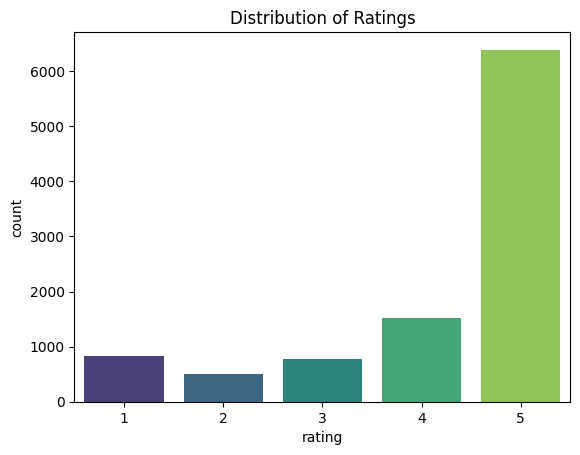

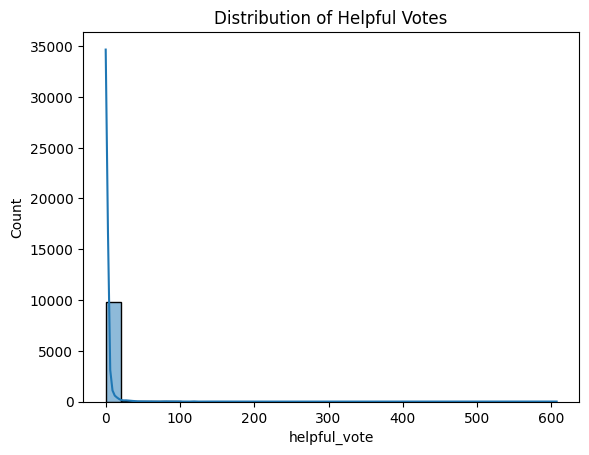

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rating distribution
sns.countplot(x='rating', data=df, palette='viridis')
plt.title("Distribution of Ratings")
plt.show()

# Helpful votes
sns.histplot(df['helpful_vote'], bins=30, kde=True)
plt.title("Distribution of Helpful Votes")
plt.show()


In [113]:
pip install seaborn

Error processing line 1 of /opt/miniconda3/envs/clickhouse_sql_Env/lib/python3.12/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 206, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/8.1 MB 284.1 kB/s eta 0:00:23
Resuming download matplotlib-3.10.7-cp312-cp312-macosx_11_0_arm64.whl (1.8 MB/8.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 290.2 kB/s  0:00:21 eta 0:00:01
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (

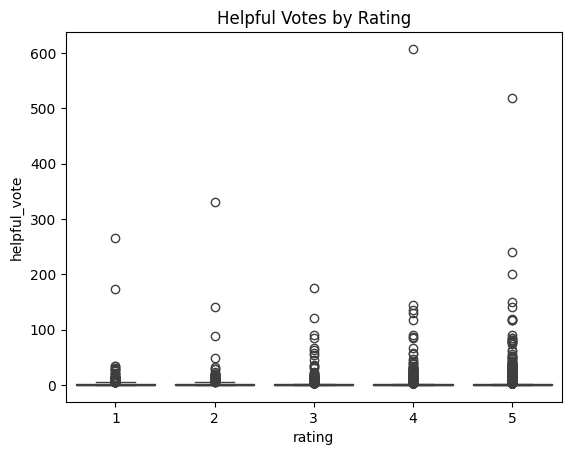

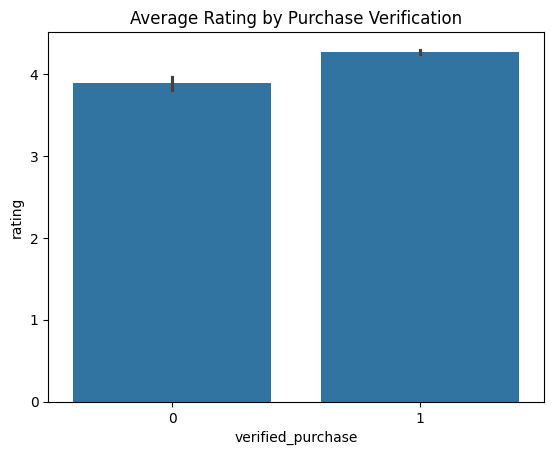

In [115]:
# Helpful votes vs rating
sns.boxplot(x='rating', y='helpful_vote', data=df)
plt.title("Helpful Votes by Rating")
plt.show()

# Verified purchase vs rating
sns.barplot(x='verified_purchase', y='rating', data=df)
plt.title("Average Rating by Purchase Verification")
plt.show()

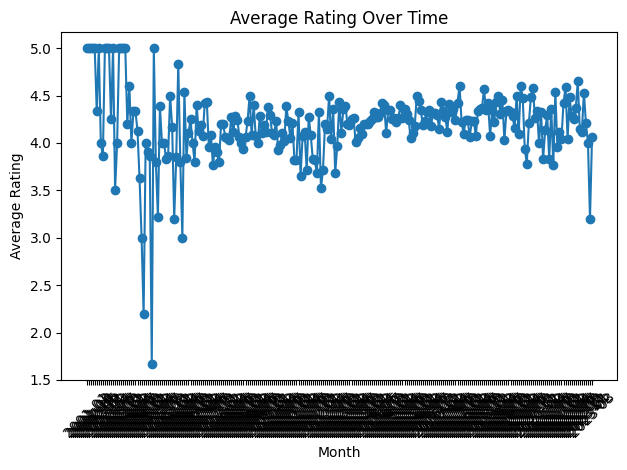

In [116]:
# Convert timestamp if needed
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Average rating per month
df['month'] = df['timestamp'].dt.to_period('M')
monthly_avg = df.groupby('month')['rating'].mean().reset_index()

plt.plot(monthly_avg['month'].astype(str), monthly_avg['rating'], marker='o')
plt.xticks(rotation=45)
plt.title("Average Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()